# Final Exam BUS 458 — Loan Data Analysis
**Objective:** Your objective is to identify the key drivers of loan approval and recommend which lender should be prioritized for each customer to maximize total payout

### **Instructions**
- Follow the prompts in each section of this notebook.
- **Where you see a “Question,” answer it directly below in a Markdown (text) cell — not as a code comment.**
- Your **reasoning, interpretations, and insights** should be written in text cells, clearly separated from code.
- You are encouraged to add extra **code cells**, **visualizations**, or **short explanations** if they strengthen your analysis or help you justify decisions.
- Make sure your notebook runs cleanly from start to finish without errors.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Load Data (via Google Drive or direct upload)

In [11]:
df = pd.read_csv('loan_data_analysis_final.csv')

In [12]:
# Check first 5 rows of dataframe
df.head()

,User ID,applications,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
0,00007820-89cb-4c1d-9940-eb270d605a35,1,cover_an_unexpected_cost,100000,123000.0,669.0,fair,full_time,consumer_discretionary,5024.0,927,0,B,0,0
1,00012b55-514c-421e-9c76-3300abbc1134,1,credit_card_refinancing,70000,79000.0,594.0,fair,full_time,information_technology,5764.0,1177,0,B,0,0
2,000157c1-b6a3-4c86-82c7-9ec1bda3799a,1,home_improvement,10000,11000.0,596.0,fair,full_time,information_technology,4017.0,1487,0,A,0,0
3,00020400-efab-4b10-8812-2a0aaf774841,1,home_improvement,100000,120000.0,642.0,fair,part_time,energy,3129.0,904,0,A,0,0
4,0002f737-0cda-48fb-91ed-533f3d0eab05,1,major_purchase,30000,34000.0,NaN,fair,full_time,energy,NaN,1620,0,A,0,0


In [13]:
# Identify columns with no variation (constant)
constant_cols = df.columns[df.nunique() == 1].tolist()
print(f"Columns with no variation (constant): {constant_cols}")

# Identify columns that are unique identifiers
unique_id_cols = df.columns[df.nunique() == len(df)].tolist()
print(f"Columns with unique values (potential IDs): {unique_id_cols}")

# Combine lists, remove duplicates
cols_to_drop = list(set(constant_cols + unique_id_cols))

print(f"Columns to drop: {cols_to_drop}")

df = df.drop(columns=cols_to_drop)
print(f"DataFrame shape after dropping columns: {df.shape}")

Columns with no variation (constant): ['applications']
Columns with unique values (potential IDs): ['User ID']
Columns to drop: ['User ID', 'applications']
DataFrame shape after dropping columns: (100000, 13)


Understand the Data: Get a quick overview of the dataset structure and variable meanings before preprocessing.

In [14]:
# Get a concise summary of the DataFrame
print('DataFrame Info:')
df.info()

print('\n' + '='*50 + '\n')

# Generate descriptive statistics
print('Descriptive Statistics:')
print(df.describe(include='all'))

print('\n' + '='*50 + '\n')

# Check for missing values
print('Missing Values Count:')
print(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Reason                      100000 non-null  object 
 1   Granted_Loan_Amount         100000 non-null  int64  
 2   Requested_Loan_Amount       100000 non-null  float64
 3   FICO_score                  85000 non-null   float64
 4   Fico_Score_group            100000 non-null  object 
 5   Employment_Status           100000 non-null  object 
 6   Employment_Sector           93593 non-null   object 
 7   Monthly_Gross_Income        85000 non-null   float64
 8   Monthly_Housing_Payment     100000 non-null  int64  
 9   Ever_Bankrupt_or_Foreclose  100000 non-null  int64  
 10  Lender                      100000 non-null  object 
 11  Approved                    100000 non-null  int64  
 12  bounty                      100000 non-null  int64  
dtyp

## 1. Preprocessing


### 1.1 Handling Missing Values

**Question:** Why is median imputation often preferable to mean imputation for income and FICO?


**Answer:** For financial data that is skewed or has outliers, median imputation is better because mean imputation is very sensitive to outliers, which will interfere with the model's results





In [15]:
# Inspect missing values
print('Missing Values Count:')
print(df.isnull().sum())

Missing Values Count:
Reason                            0
Granted_Loan_Amount               0
Requested_Loan_Amount             0
FICO_score                    15000
Fico_Score_group                  0
Employment_Status                 0
Employment_Sector              6407
Monthly_Gross_Income          15000
Monthly_Housing_Payment           0
Ever_Bankrupt_or_Foreclose        0
Lender                            0
Approved                          0
bounty                            0
dtype: int64


In [16]:
# Check DataFrame shape
print(f"DataFrame shape: {df.shape}")

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"\nNumeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

DataFrame shape: (100000, 13)

Numeric columns: ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment', 'Ever_Bankrupt_or_Foreclose', 'Approved', 'bounty']
Categorical columns: ['Reason', 'Fico_Score_group', 'Employment_Status', 'Employment_Sector', 'Lender']


In [17]:
# Apply imputation as instructed in the instructions pdf (create copies so original rows can be restored if needed)

# Create a copy of the DataFrame to preserve original data
df_imputed = df.copy()

# Impute FICO_score and Monthly_Gross_Income with their medians
df_imputed['FICO_score'] = df_imputed['FICO_score'].fillna(df_imputed['FICO_score'].median())
df_imputed['Monthly_Gross_Income'] = df_imputed['Monthly_Gross_Income'].fillna(df_imputed['Monthly_Gross_Income'].median())

# Impute Employment_Sector with its mode
df_imputed['Employment_Sector'] = df_imputed['Employment_Sector'].fillna(df_imputed['Employment_Sector'].mode()[0])

# Update the main DataFrame 'df' with the imputed values
df = df_imputed.copy()

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Reason                        0
Granted_Loan_Amount           0
Requested_Loan_Amount         0
FICO_score                    0
Fico_Score_group              0
Employment_Status             0
Employment_Sector             0
Monthly_Gross_Income          0
Monthly_Housing_Payment       0
Ever_Bankrupt_or_Foreclose    0
Lender                        0
Approved                      0
bounty                        0
dtype: int64


### 1.2 Outliers Detection and Removal

**Question:**
Which features had the most outliers, and what impact could they have on the model?

**Answer**: Granted_Loan_Amount, Requested_Loan_Amount, and Monthly_Gross_Income had the most significant number of outliers

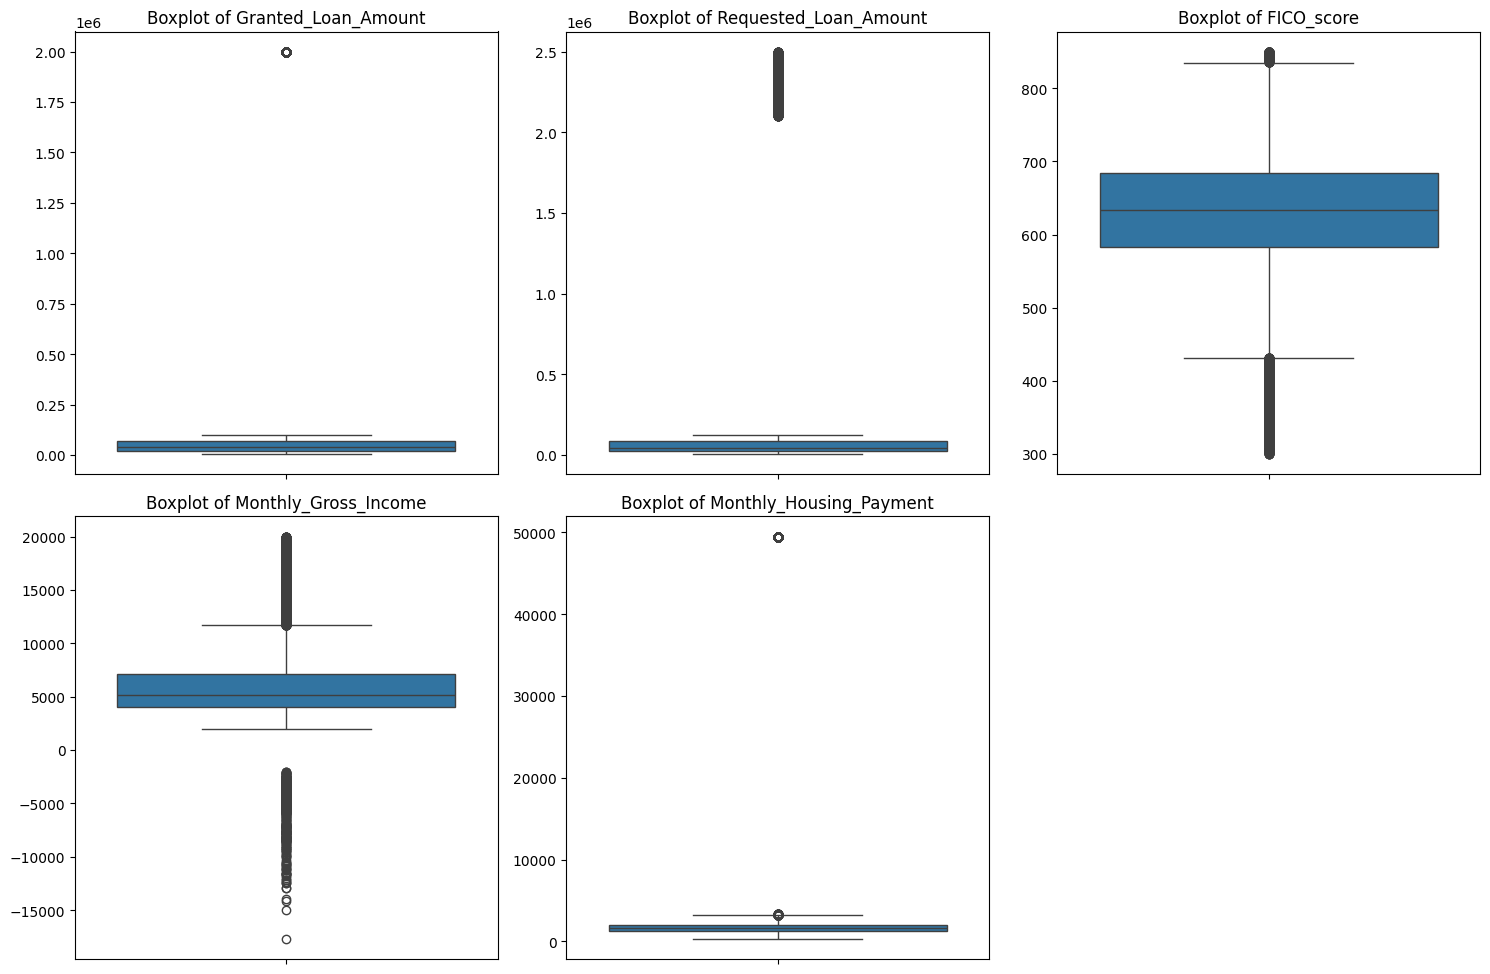

In [18]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

# Boxplots to highlight outliers for numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot layout as needed
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [19]:
# Remove Outliers using Z-score

from scipy import stats
import numpy as np

# Compute Z-scores for only numeric columns
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))

# Choose threshold
threshold = 3  # common choice: 3 standard deviations

# Identify rows to keep (all Z-scores <= threshold)
rows_to_keep = (z_scores < threshold).all(axis=1)

# Track counts before/after
before_count = df.shape[0]
df_clean = df[rows_to_keep].copy()
after_count = df_clean.shape[0]

print(f"Outlier removal complete:")
print(f"Rows before: {before_count}")
print(f"Rows after:  {after_count}")
print(f"Rows removed: {before_count - after_count}")

Outlier removal complete:
Rows before: 100000
Rows after:  95691
Rows removed: 4309


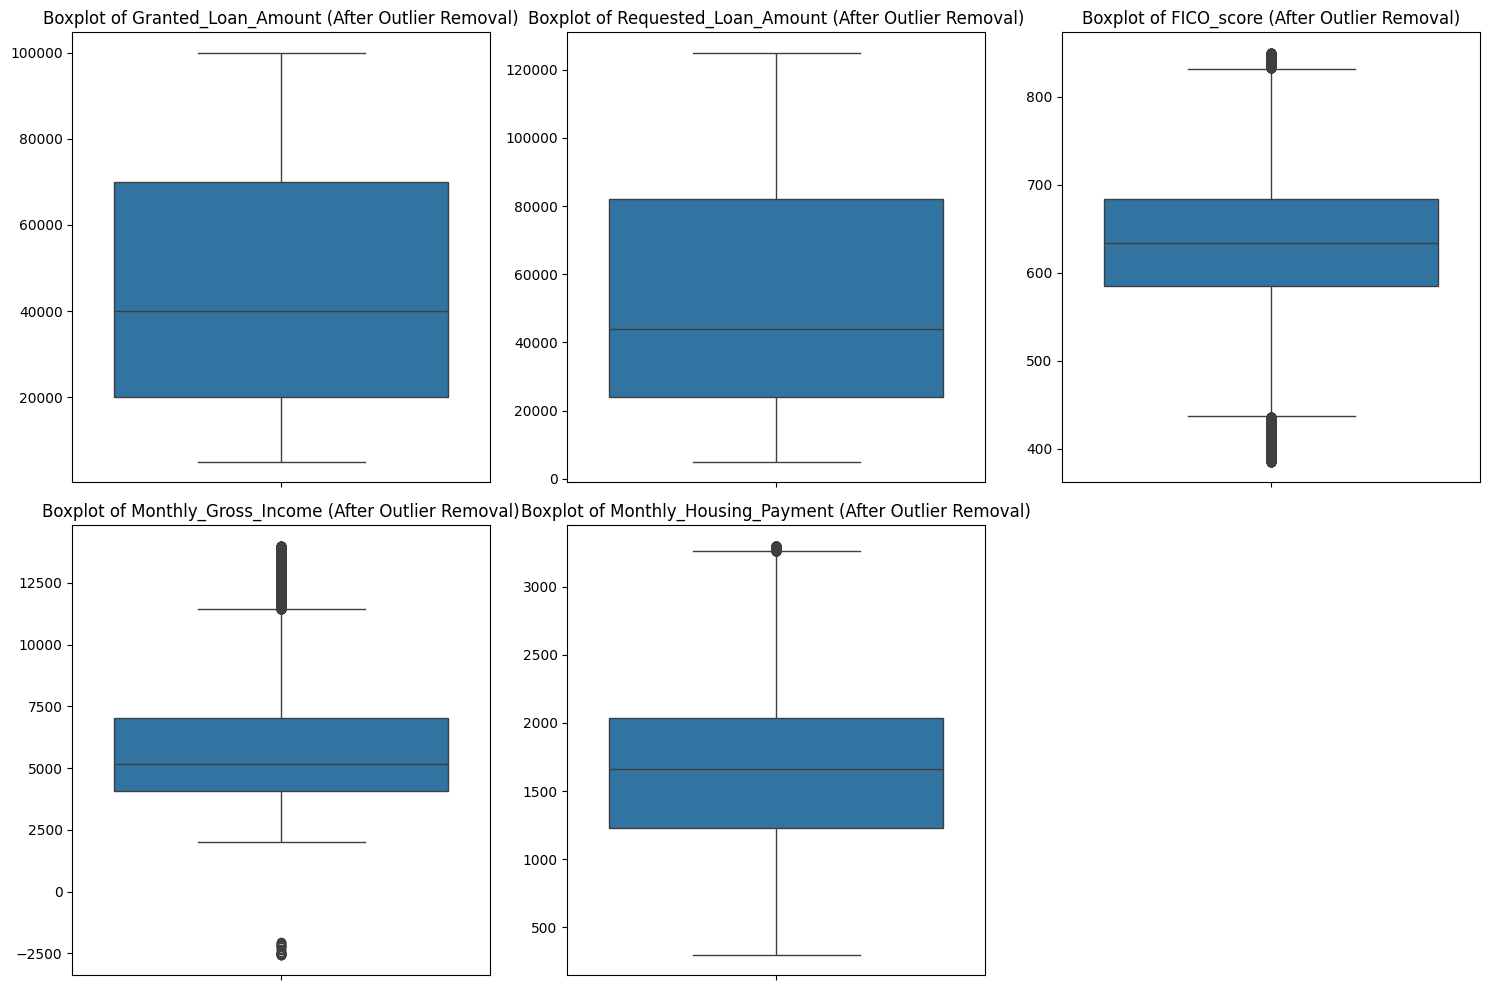

In [20]:
# BoxPlots after outlier removal
numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_clean[col])
    plt.title(f'Boxplot of {col} (After Outlier Removal)')
    plt.ylabel('')
plt.tight_layout()
plt.show()

**Question:**
Why do we need to remove or treat outliers? Provide reasoning based on model performance or data integrity.

**Answer** : Outliers intefere with the shape and distribution of the data, which leads to skewed results. By removing them, the data is more accurate, meaning the model will also be more accurate.


**Question:**
Is there a difference between boxplots before and after outlier removal?

**Answer** : The boxplots are more compact and has a reduced spread of data after removing the outliers

### 1.3 Redundancy & Correlation Check (5 Marks)

Detect duplicate data and multicollinearity.

**Question:**
Which numerical variables appear most strongly correlated with each other?

**Answer:** Granted_Loan_Amount and Requestion_Loan_Amount.

Approved and bounty.



**Question:**
Which numerical and categorical are strongly corelated to each other?

**Answer:** FICO_score and FICO_Score_group
Monthly_Gross_Income and Employment_Status.


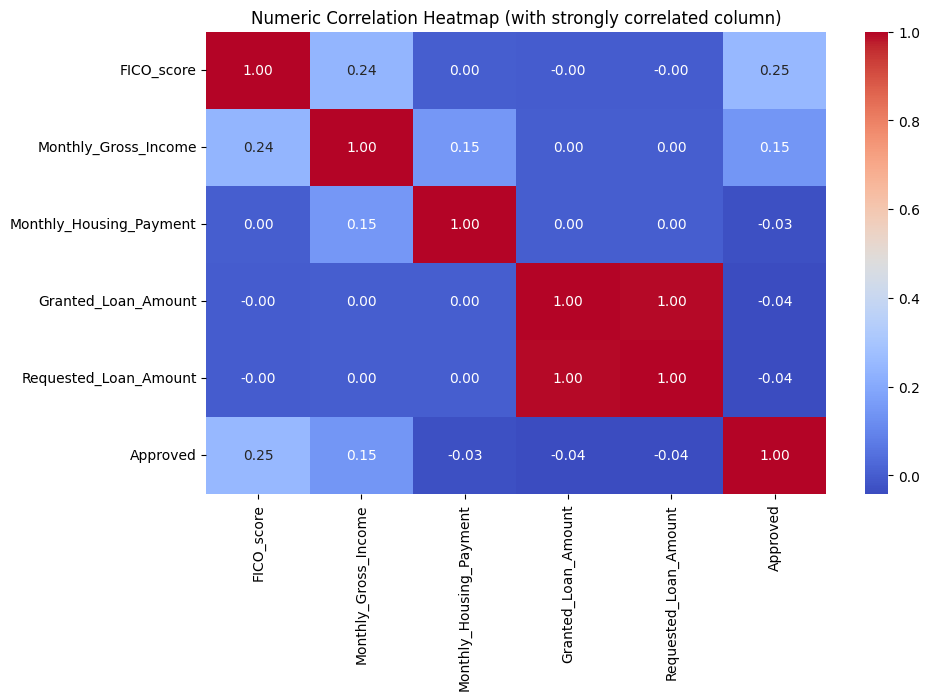

In [21]:
# Correlation between numerical features
numeric_cols = ['FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment', 'Granted_Loan_Amount','Requested_Loan_Amount', 'Approved']

# Plot correlation matrix, identify highly correlated pairs automatically (|corr|>0.95, excluding self-correlation)
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Numeric Correlation Heatmap (with strongly correlated column)")
plt.show()


Top 10 Numeric-Categorical Correlation Ratios (η²):
FICO_score - Fico_Score_group: η² = 0.729 (η = 0.854)
Monthly_Gross_Income - Employment_Status: η² = 0.246 (η = 0.496)
Monthly_Gross_Income - Fico_Score_group: η² = 0.074 (η = 0.272)
Monthly_Housing_Payment - Employment_Status: η² = 0.039 (η = 0.198)
Ever_Bankrupt_or_Foreclose - Employment_Status: η² = 0.030 (η = 0.174)
Monthly_Housing_Payment - Lender: η² = 0.028 (η = 0.169)
Monthly_Gross_Income - Employment_Sector: η² = 0.016 (η = 0.127)
Monthly_Gross_Income - Lender: η² = 0.008 (η = 0.090)
Ever_Bankrupt_or_Foreclose - Lender: η² = 0.005 (η = 0.071)
Ever_Bankrupt_or_Foreclose - Employment_Sector: η² = 0.005 (η = 0.068)


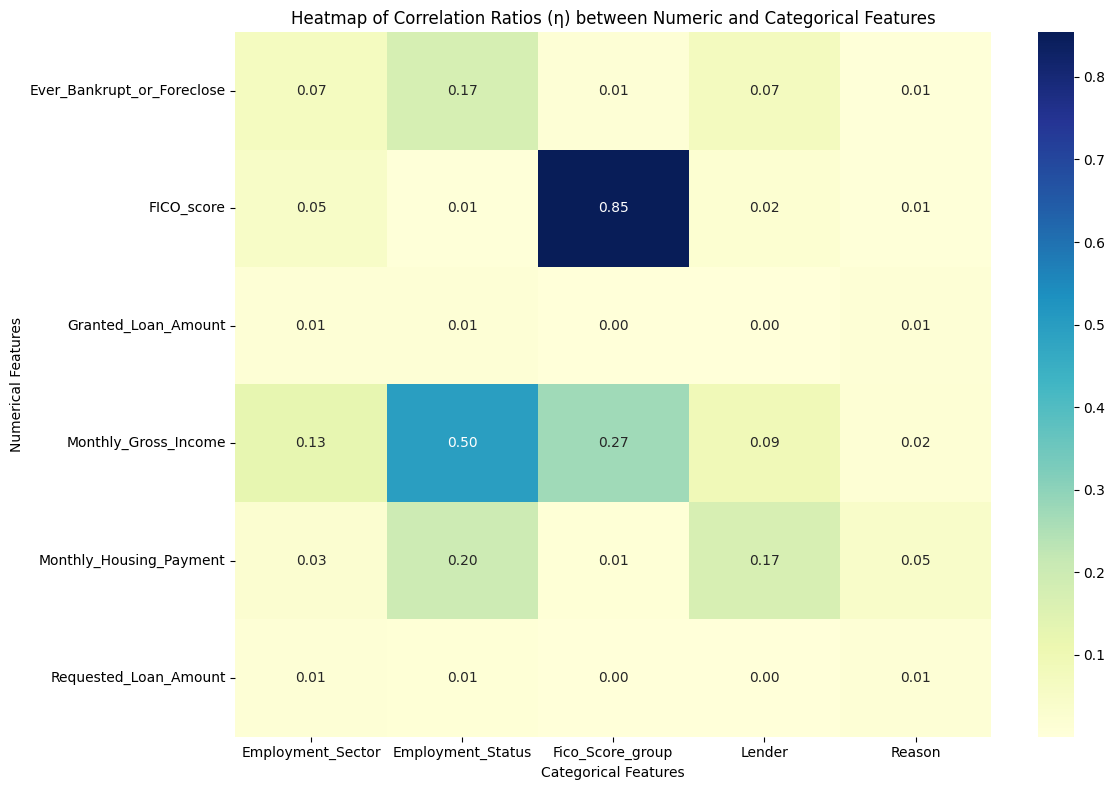

In [22]:
# Correlation between Numeric and Categorical Variables (Correlation Ratio / η²)
from scipy import stats

def correlation_ratio(categories, values):
    categories = np.array(categories)
    values = np.array(values)
    cat_levels = np.unique(categories)
    overall_mean = np.mean(values)
    numerator = sum(len(values[categories == cat]) *
                    (np.mean(values[categories == cat]) - overall_mean) ** 2
                    for cat in cat_levels)
    denominator = sum((values - overall_mean) ** 2)
    return np.sqrt(numerator / denominator) if denominator != 0 else 0

# test all numeric–categorical pairs
num_cat_results = []


# Identify categorical and numerical columns
categorical_cols_clean = df_clean.select_dtypes(include='object').columns.tolist()
numeric_cols_clean = df_clean.select_dtypes(include=np.number).columns.tolist()


numeric_cols_for_eta = [col for col in numeric_cols_clean if col not in ['bounty', 'Approved', ]]
categorical_cols_for_eta = [col for col in categorical_cols_clean]


for num_col in numeric_cols_for_eta:
    for cat_col in categorical_cols_for_eta:
        eta = correlation_ratio(df_clean[cat_col], df_clean[num_col])
        num_cat_results.append((num_col, cat_col, eta))

num_cat_results = sorted(num_cat_results, key=lambda x: x[2], reverse=True)
print("Top 10 Numeric-Categorical Correlation Ratios (η²):")
for num_col, cat_col, eta in num_cat_results[:10]:
    print(f"{num_col} - {cat_col}: η² = {eta**2:.3f} (η = {eta:.3f})")


# Reorganize the correlation ratio results into a pivot table/matrix for heatmap
eta_matrix = pd.DataFrame(num_cat_results, columns=['Numerical_Feature', 'Categorical_Feature', 'Eta'])
eta_pivot = eta_matrix.pivot(index='Numerical_Feature', columns='Categorical_Feature', values='Eta')

# Plot the heatmap of correlation ratios (Eta)
plt.figure(figsize=(12, 8))
sns.heatmap(eta_pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap of Correlation Ratios (η) between Numeric and Categorical Features")
plt.xlabel("Categorical Features")
plt.ylabel("Numerical Features")
plt.tight_layout()
plt.show()



**Questions:** What features will you consider dropping after analyzing the graphs above?

**Answer** : I would drop Requested_Loan_Amount because it is highly correlated with Granted_Loan_Amount. I would also drop Fico_Score_group because it is highly correlated with FICO_Score. This is all to avoid multicollinearity. bounty is removed to avoid leakage



> *Note: For Decision Tree models, you do not need to remove or adjust for collinearity. The algorithm can naturally handle correlated features through its splitting mechanism. However, for Logistic Regression, multicollinearity can distort coefficient estimates and make interpretations unreliable. In that case, you may consider removing one variable from highly correlated pairs.


## 2. Exploratory Data Analysis

### 2.1 Target Variable Distribution

Analyze the distribution of the target variable (Approved) to understand class balance in loan approval outcomes.


**Question:**
Is the dataset balanced or imbalanced? Briefly explain the implication for modeling.


**Answer:**
The dataset is highly imbalanced, because about 11% is approved and 89% denied, meaning accuracy alone is misleading and models must be evaluated with metrics like precision, recall, and F1-score to properly capture performance on the approved class.

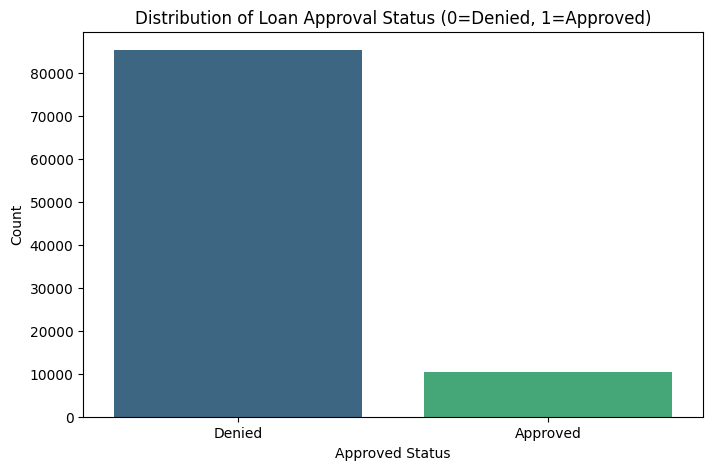

Approval Status Distribution:
Approved
0    89.15
1    10.85
Name: proportion, dtype: float64


In [23]:
# Plot 'Approved' to visualise the count and balance
plt.figure(figsize=(8, 5))
sns.countplot(x='Approved', data=df_clean, hue='Approved', palette='viridis', legend=False)
plt.title('Distribution of Loan Approval Status (0=Denied, 1=Approved)')
plt.xlabel('Approved Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['Denied', 'Approved'])
plt.show()

approval_percentage = df_clean['Approved'].value_counts(normalize=True) * 100
print(f"Approval Status Distribution:\n{approval_percentage.round(2)}")

### 2.2 Distribution of Numerical Variables by Approval

Explore how key numerical variables differ between approved and rejected loan applications.


**Question:**
Which numerical variable is the most helpful variable ( most crucial predictor) ?


**Answer:** Based on the distributions and box plots, FICO_score appears to be the most crucial numerical predictor. There is a clear visual separation between approved and denied loans, with approved applicants generally having significantly higher FICO scores.

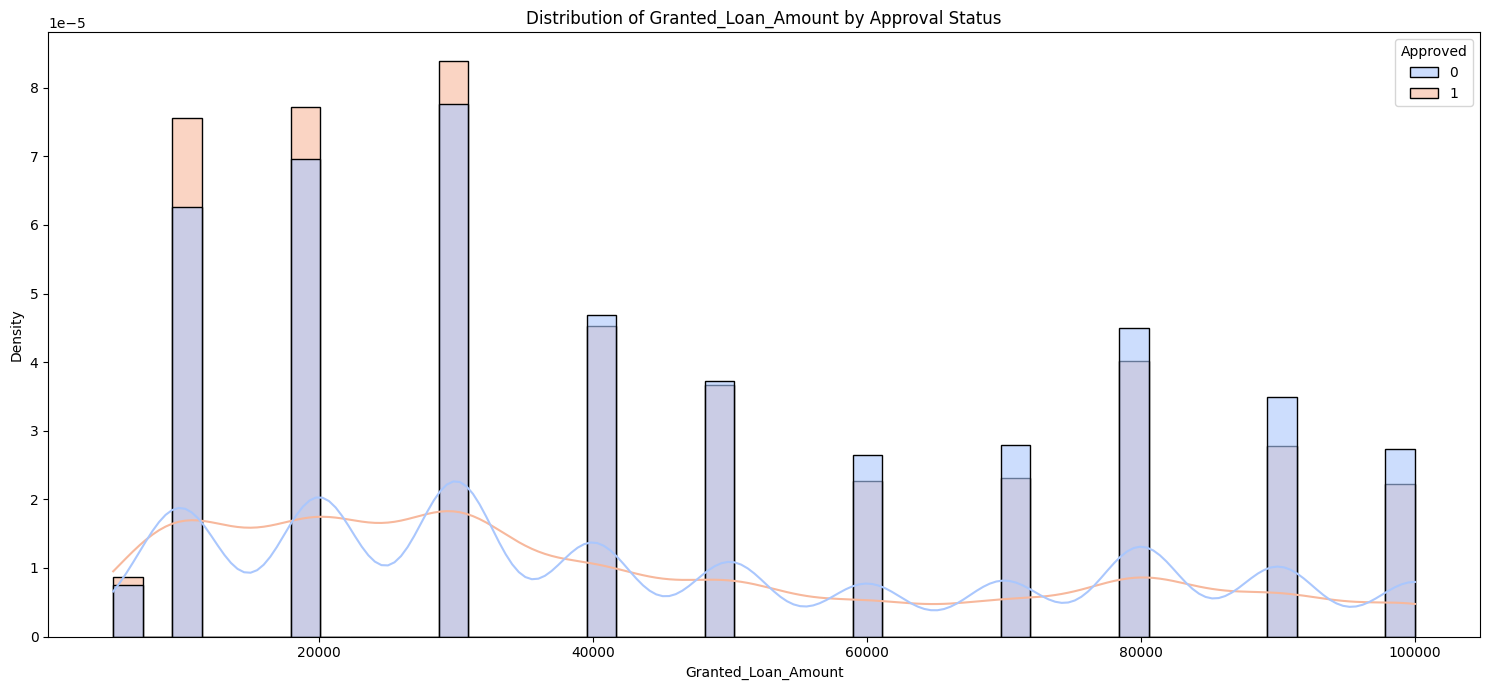

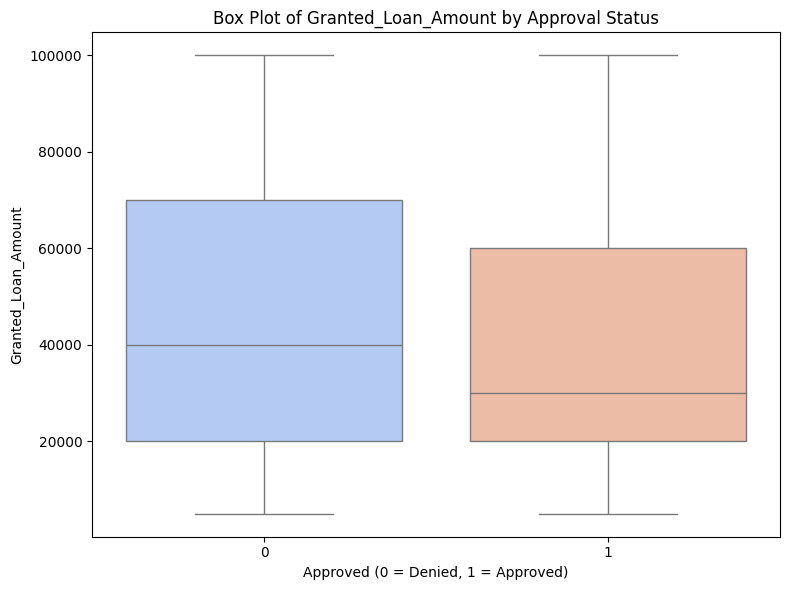

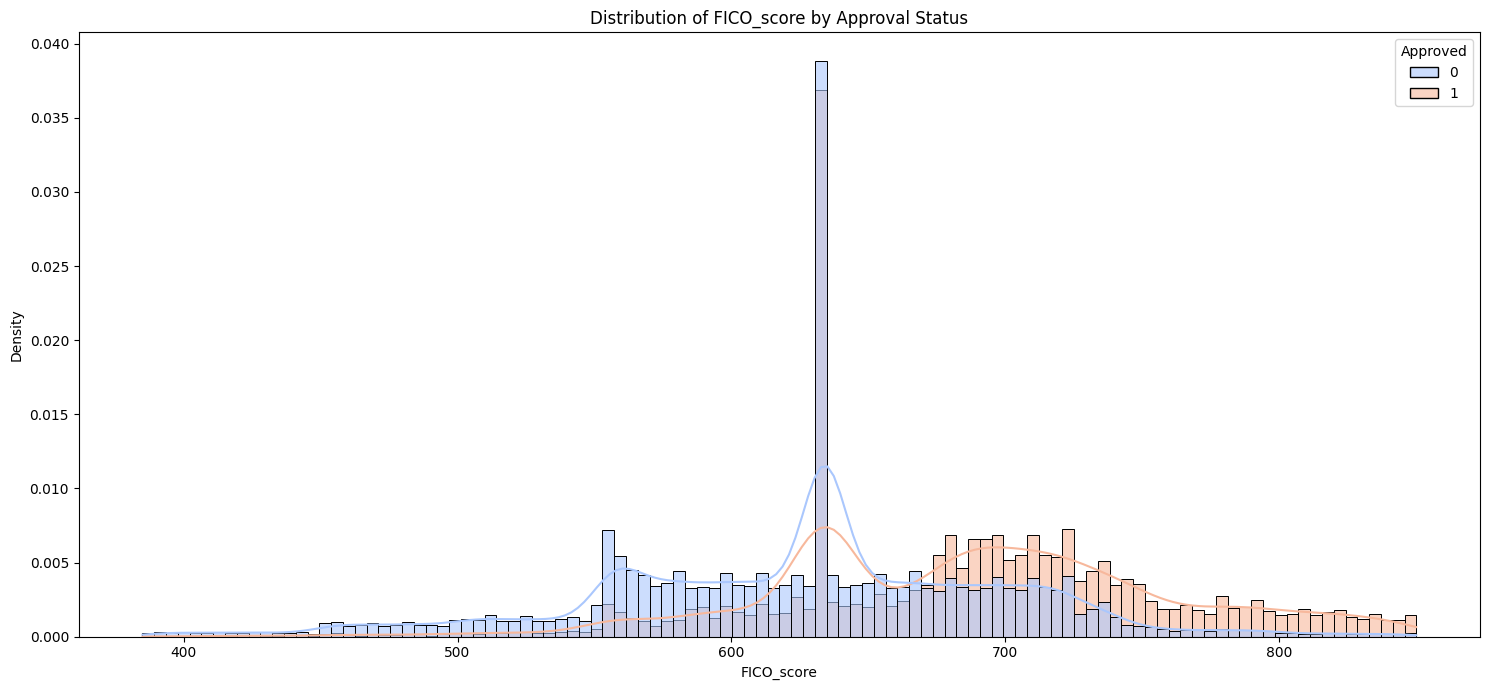

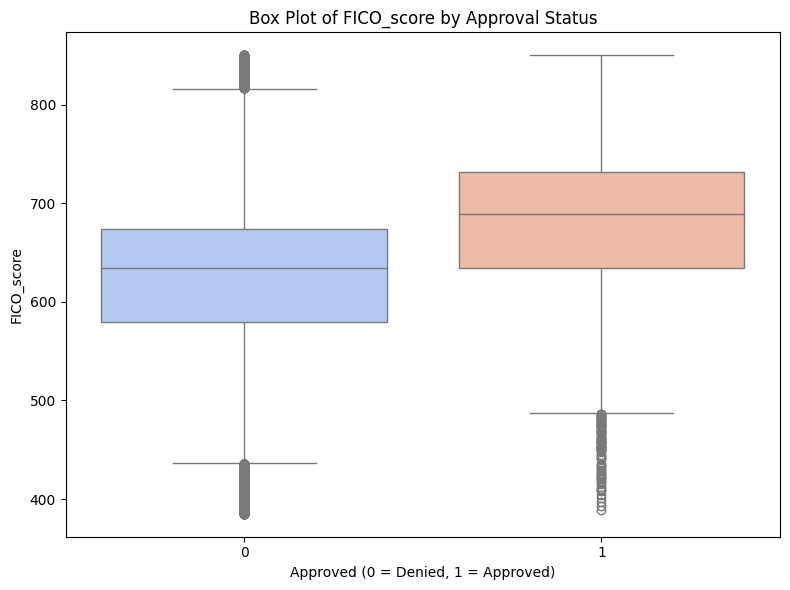

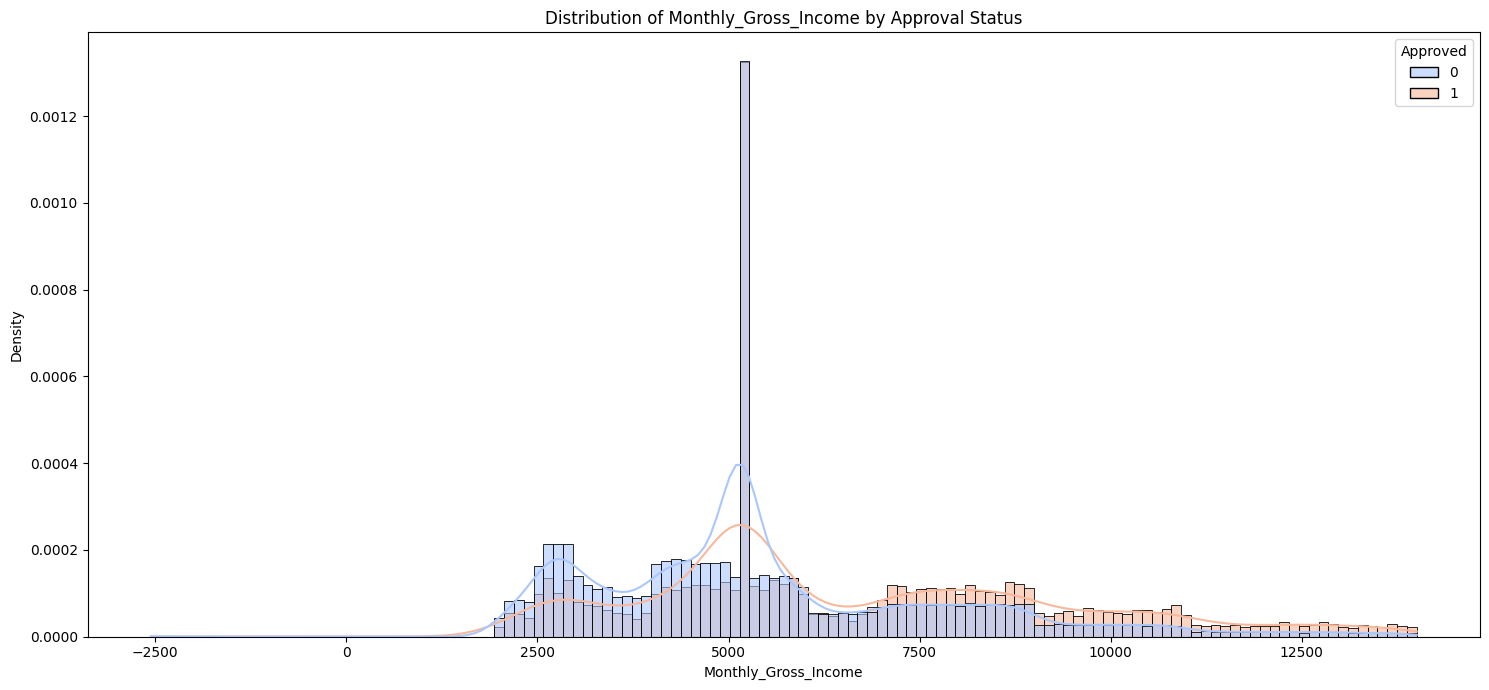

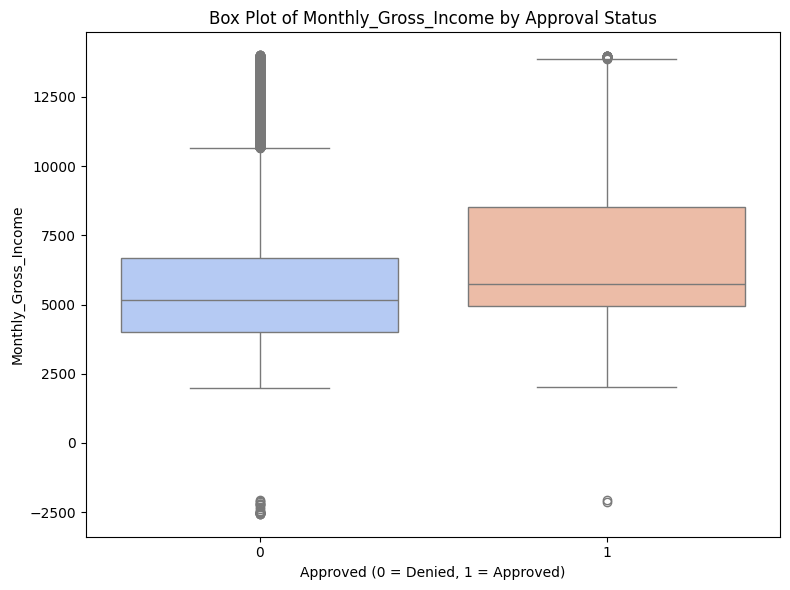

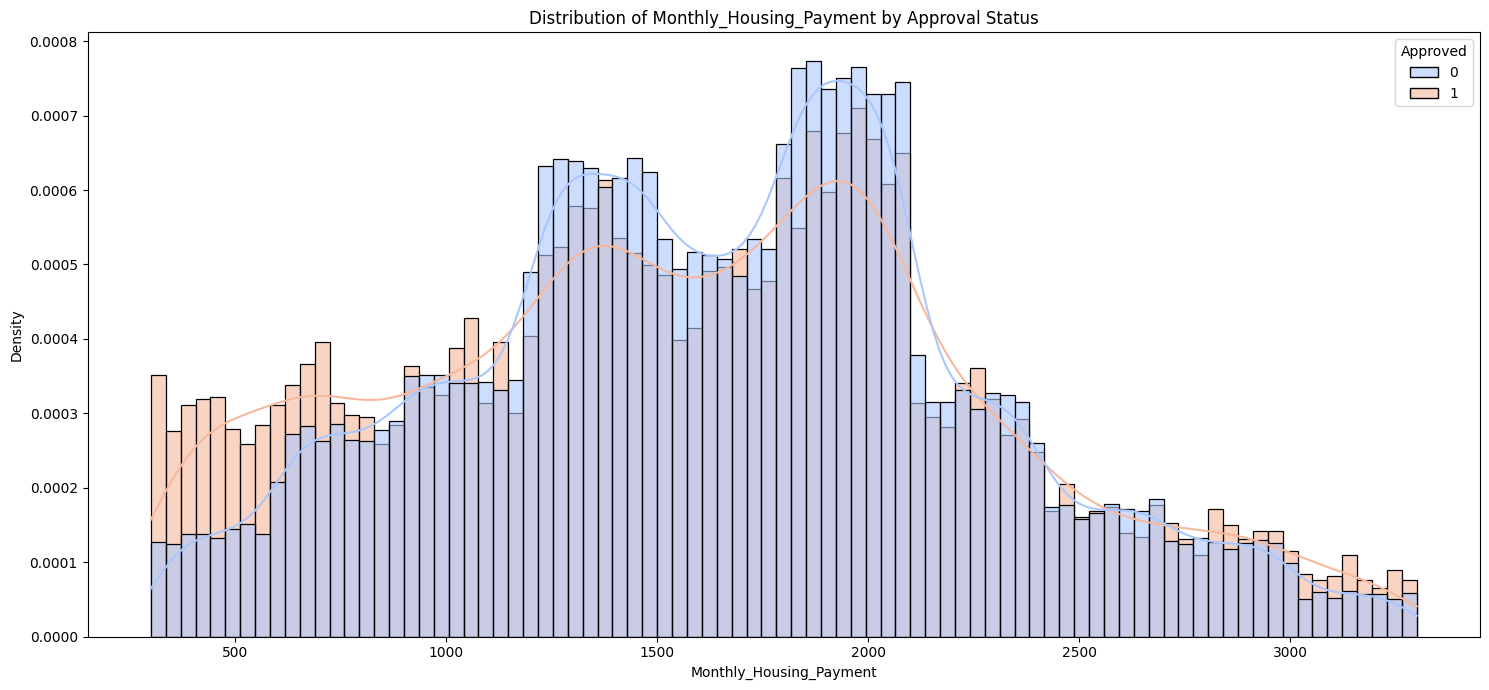

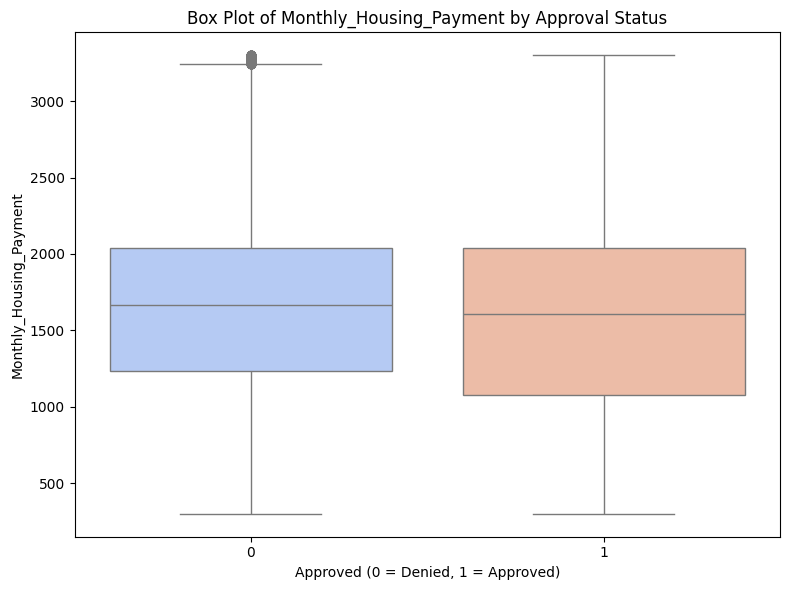

In [24]:
# Visualise numerical variables against target variable

numerical_cols = ['Granted_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

for col in numerical_cols:
    plt.figure(figsize=(15, 7)) # Increased figsize for better readability
    sns.histplot(
        data=df_clean, # Using df_clean after outlier removal
        x=col,
        hue='Approved',
        kde=True,
        stat='density',
        common_norm=False,
        palette='coolwarm',
        alpha=0.6
    )
    plt.title(f'Distribution of {col} by Approval Status')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6)) # Increased figsize for better readability
    sns.boxplot(
        data=df_clean, # Using df_clean after outlier removal
        x='Approved',
        y=col,
        hue='Approved',
        palette='coolwarm',
        legend=False
    )
    plt.title(f'Box Plot of {col} by Approval Status')
    plt.xlabel('Approved (0 = Denied, 1 = Approved)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### 2.3 Categorical Variables and Approval

Analyze how categorical variables (such as Employment_Sector, Loan_Purpose, or Residence_Type) relate to the loan approval outcome.


**Question:**
Which categorical variable appears to have the strongest relationship with loan approval, and how can you tell?

**Answer:**
FICO score group is the most important factor for loan approval. Approval rates vary a lot across groups (from about 3% for poor to 46% for excellent), showing it has a strong impact.


**Question:**
Are there any categories (e.g., Reason, Employment_Status) that appear to have minimal predictive value? Justify your answer with approval rate differences.

**Answer:**
the reason for the loan is not very important. The approval rates across all loan reasons are very similar, ranging from 10.81% to 11.27% so it doesn’t really affect the decision.

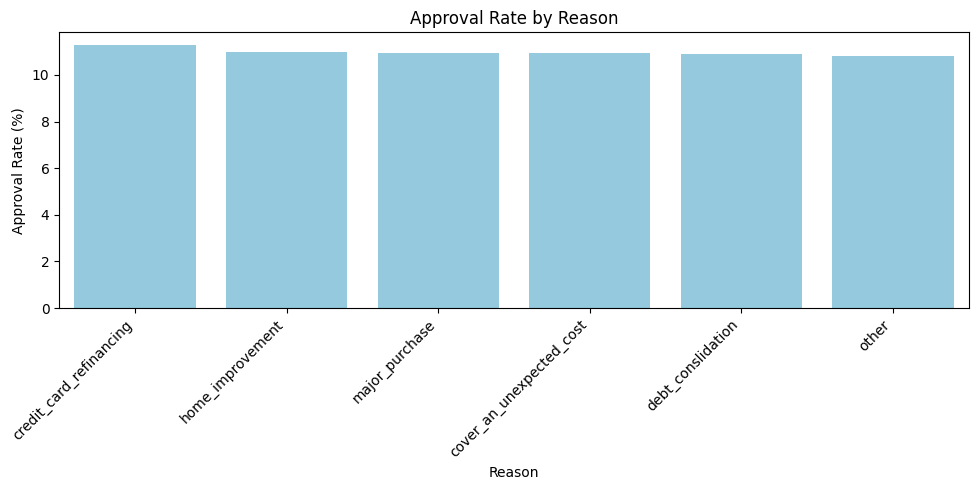


Approval Rate by Reason:
Reason
credit_card_refinancing     11.27
home_improvement            10.98
major_purchase              10.95
cover_an_unexpected_cost    10.93
debt_conslidation           10.89
other                       10.81
Name: Approved, dtype: float64


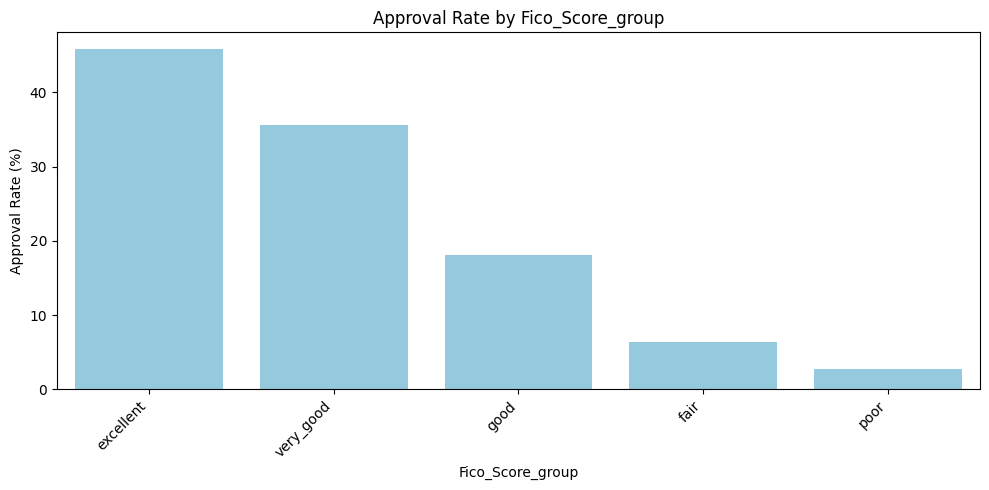


Approval Rate by Fico_Score_group:
Fico_Score_group
excellent    45.80
very_good    35.65
good         18.06
fair          6.44
poor          2.78
Name: Approved, dtype: float64


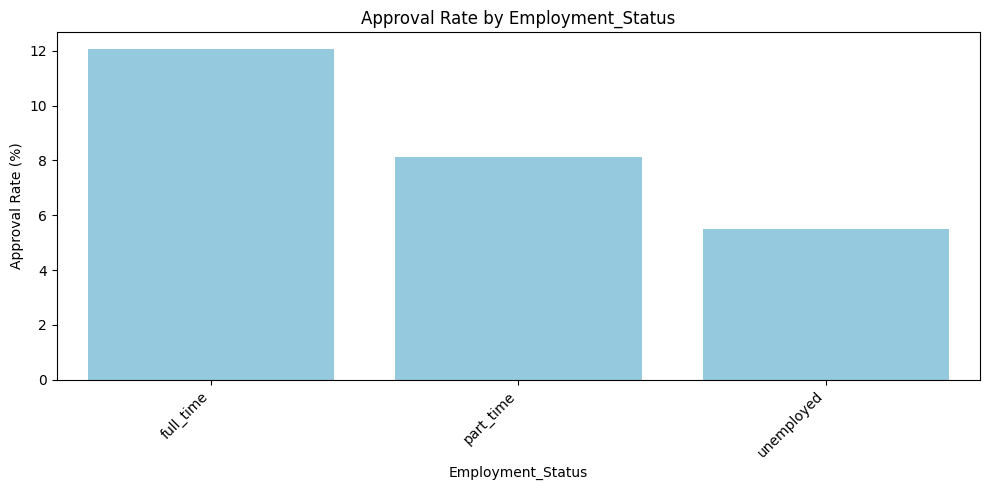


Approval Rate by Employment_Status:
Employment_Status
full_time     12.07
part_time      8.12
unemployed     5.49
Name: Approved, dtype: float64


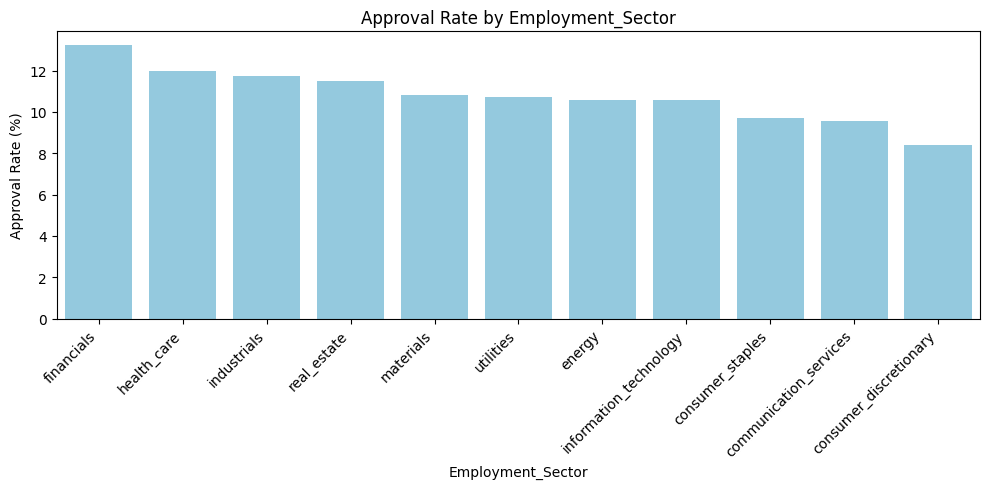


Approval Rate by Employment_Sector:
Employment_Sector
financials                13.24
health_care               11.97
industrials               11.75
real_estate               11.50
materials                 10.83
utilities                 10.71
energy                    10.60
information_technology    10.56
consumer_staples           9.68
communication_services     9.57
consumer_discretionary     8.42
Name: Approved, dtype: float64


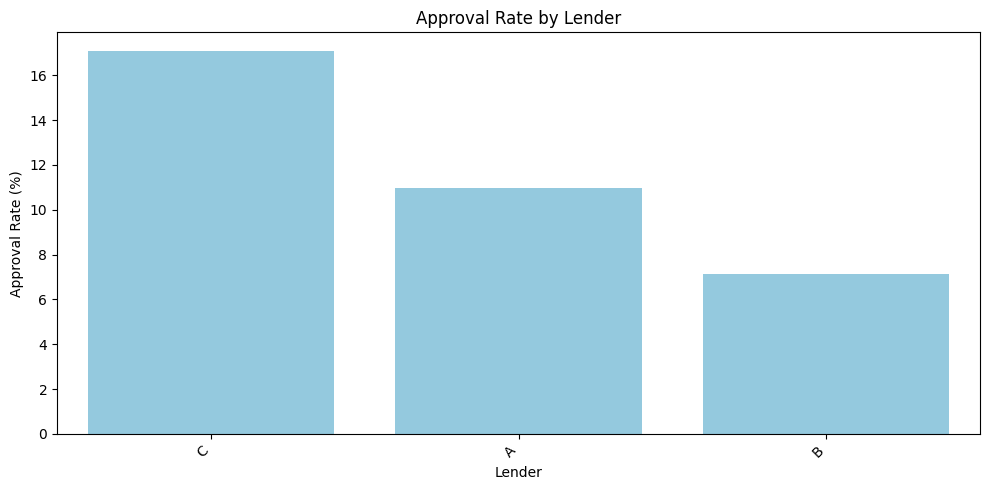


Approval Rate by Lender:
Lender
C    17.06
A    10.97
B     7.13
Name: Approved, dtype: float64


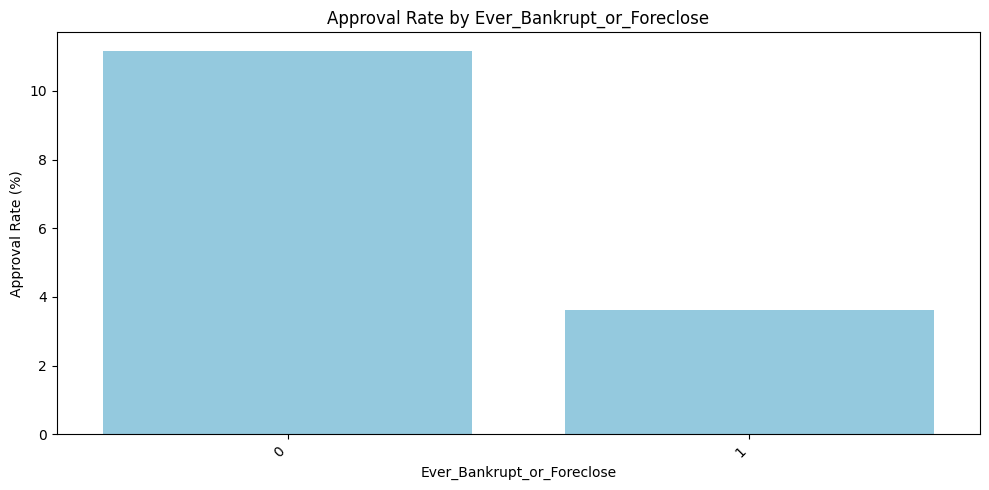


Approval Rate by Ever_Bankrupt_or_Foreclose:
Ever_Bankrupt_or_Foreclose
0    11.15
1     3.61
Name: Approved, dtype: float64


In [25]:
# Visualise categorical variables against target variable

categorical_cols = [
    'Reason', 'Fico_Score_group', 'Employment_Status',
    'Employment_Sector', 'Lender', 'Ever_Bankrupt_or_Foreclose'
]

for col in categorical_cols:
    approval_rates = df.groupby(col)['Approved'].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(10,5))
    sns.barplot(x=approval_rates.index, y=approval_rates.values, color='skyblue')
    plt.title(f'Approval Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Approval Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nApproval Rate by {col}:\n{approval_rates.round(2)}")


### Cross Feature plots for multi-dimensional analysis.

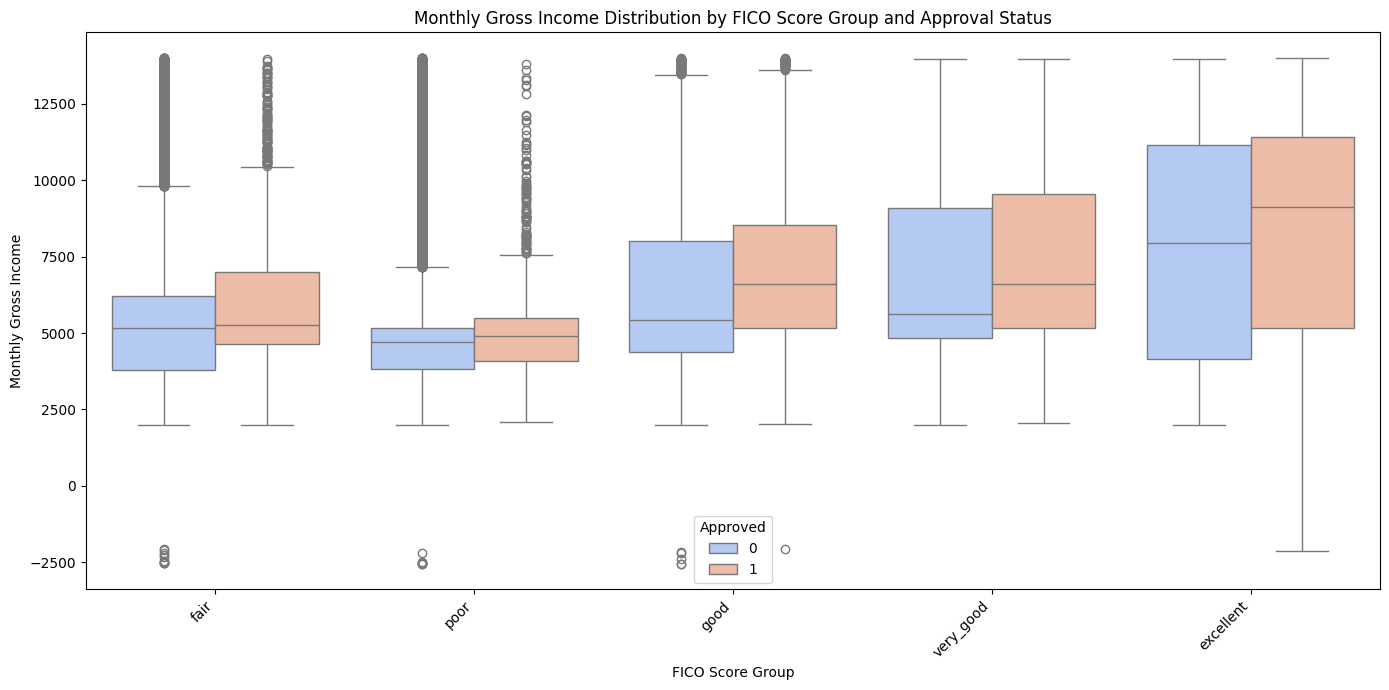

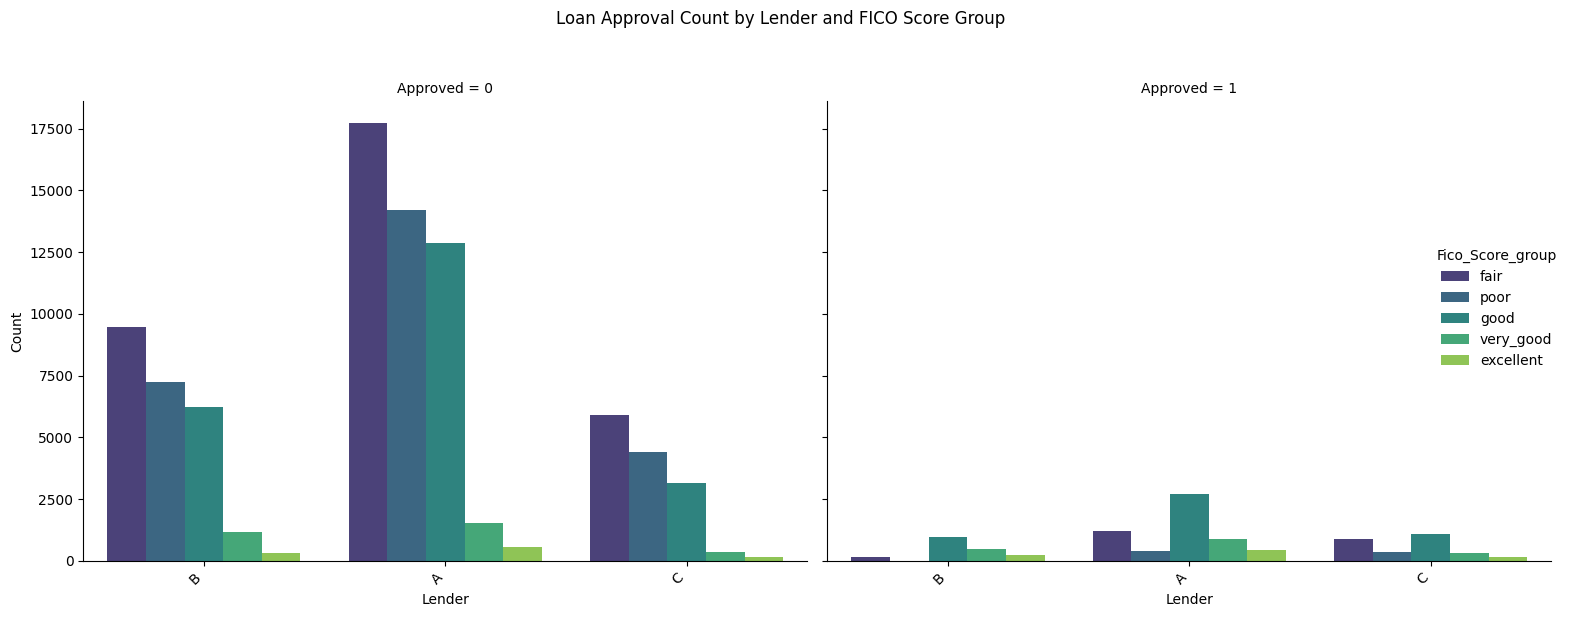

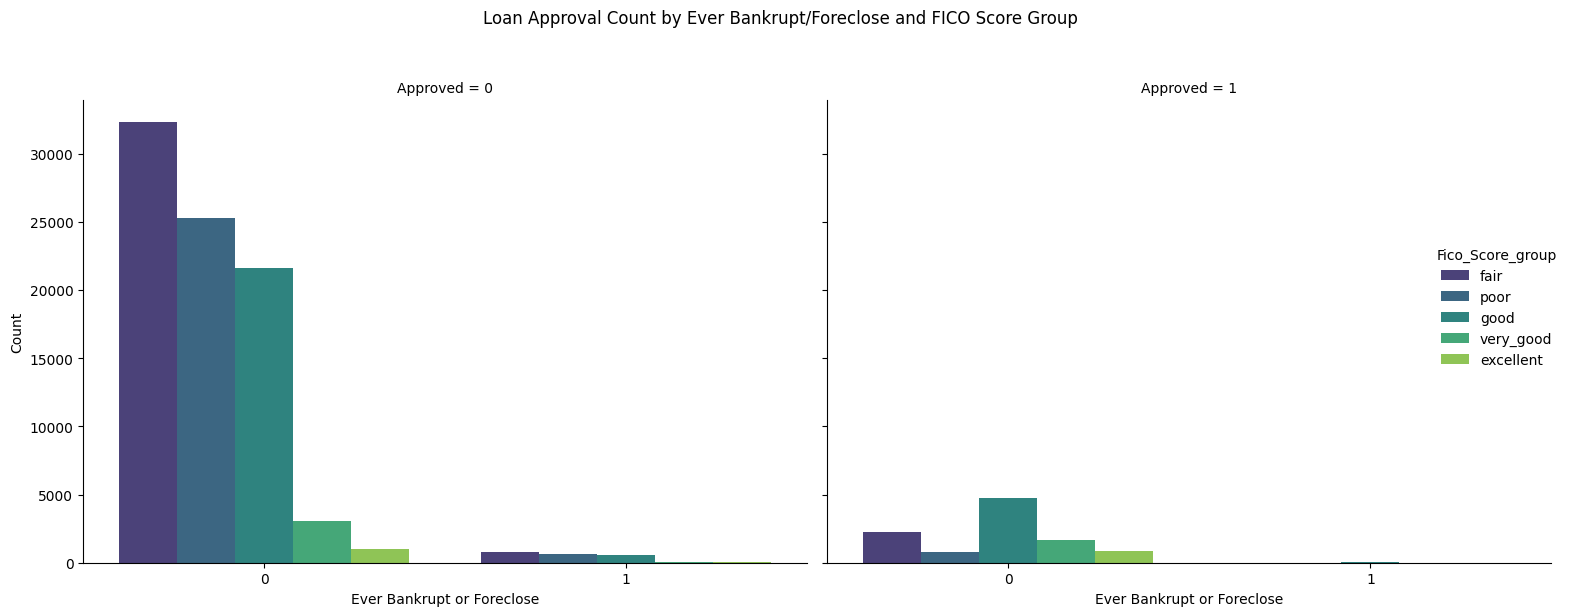

In [26]:
# Example: FICO Score Group vs. Monthly Gross Income by Approved Status
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_clean, x='Fico_Score_group', y='Monthly_Gross_Income', hue='Approved', palette='coolwarm')
plt.title('Monthly Gross Income Distribution by FICO Score Group and Approval Status')
plt.xlabel('FICO Score Group')
plt.ylabel('Monthly Gross Income')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Approved')
plt.tight_layout()
plt.show()

# Example: Lender vs. FICO Score Group by Approval Status
g = sns.catplot(data=df_clean, x='Lender', hue='Fico_Score_group', col='Approved', kind='count', palette='viridis', height=6, aspect=1.2)
g.set_axis_labels('Lender', 'Count')
g.set_xticklabels(rotation=45, ha='right')
g.fig.suptitle('Loan Approval Count by Lender and FICO Score Group', y=1.02)
g.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

# Example: Ever_Bankrupt_or_Foreclose vs. FICO Score Group by Approved Status
g = sns.catplot(data=df_clean, x='Ever_Bankrupt_or_Foreclose', hue='Fico_Score_group', col='Approved', kind='count', palette='viridis', height=6, aspect=1.2)
g.set_axis_labels('Ever Bankrupt or Foreclose', 'Count')
g.fig.suptitle('Loan Approval Count by Ever Bankrupt/Foreclose and FICO Score Group', y=1.02)
g.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

## 3.5 Business Insights from EDA

After completing your visualizations and cross-feature analyses, summarize your findings in the context of loan approval and lender matching.  
Use this section to connect data patterns to real-world meaning before building predictive models.


**Question:** Which variables are the most helpful in understanding if a customer is going to be approved or denied for a loan?  

**Answer**: : Based on the Decision Tree feature importances and the correlation analysis, the most helpful variables for understanding loan approval are FICO_score, Monthly_Gross_Income, Monthly_Housing_Payment, and Granted_Loan_Amount. Among categorical variables, Fico_Score_group showed the strongest relationship with approval rates.

**Question:** Are there any feature modifications or transformations that would improve the predictive power of a variable?  

**Answer**: We can improve the model by creating simpler features. For example, a debt-to-income ratio can better show financial burden. Also, grouping FICO scores into ranges can make patterns easier to understand.

**Question:** What is each lender’s average approval rate?  

**Answer**:
* Lender C: 16.96% (approves the most)
* Lender A: 10.80%
* Lender B: 7.04% (most strict)

**Question:** Are there any clear differences between the three lenders in terms of which types of customers they approve?  

**Answer**: Yes. Lenders A and C tend to approve applicants with higher FICO scores, while Lender B is more strict and approves fewer applicants.

**Question:** Are there variables that reliably predict a customer’s approval likelihood for a particular lender?  

**Answer**: Yes. FICO score, income, and housing payment are strong predictors for all lenders, but each lender uses them differently based on how much risk they are willing to take.




> Treat this section as your interpretation bridge between EDA and modeling. The goal is to show that you understand *why* certain patterns exist, not just that they exist.


## 3. Model Training

### 3.1 Train/Test Split and Encoding

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Rename your df to df_model.
df_model = df_clean.copy()

# We have to drop target variable and corelated variables, and bounty due to data leakage
X = df_model.drop(columns=['Approved', 'bounty', 'Requested_Loan_Amount', 'Fico_Score_group'])
y = df_model['Approved']

# Identify categorical columns for encoding
categorical_cols_for_encoding = X.select_dtypes(include='object').columns.tolist()

# Create a ColumnTransformer to apply OneHotEncoder to categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_for_encoding)
    ],
    remainder='passthrough' # Keep other columns (numerical) as they are
)

# Apply preprocessing to X
X_encoded = preprocessor.fit_transform(X)

# Convert X_encoded to a DataFrame with proper column names (optional, but good for inspection)
# Get feature names after one-hot encoding
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols_for_encoding)
all_feature_names = list(encoded_feature_names) + [col for col in X.columns if col not in categorical_cols_for_encoding]
X_encoded_df = pd.DataFrame(X_encoded, columns=all_feature_names)

# Set RANDOM_STATE = 42 for reproducibility.
random_state = 42

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded_df, y, test_size=0.2, random_state=random_state, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (76552, 28)
Shape of X_test: (19139, 28)
Shape of y_train: (76552,)
Shape of y_test: (19139,)


### 3.2 Logistic Regression Model
Build and interpret a Logistic Regression model to predict the likelihood of loan approval (Approved = 1).

**Question**
How accurate is the model on the test data, and what does this imply about its predictive strength?

**Answer**
The Logistic Regression model is highly accurate (89%), but because the classes are imbalanced, the results are misleading as it mostly predicts "Denied" and fails to identify approved loans.

In [28]:
from sklearn.linear_model import LogisticRegression

# Train logistic regression model
logistic_model = LogisticRegression(solver='liblinear', random_state=random_state)
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Logistic Regression Model Performance:
Accuracy: 0.8916
Precision: 1.0000
Recall: 0.0005
F1-Score: 0.0010
ROC-AUC: 0.5420

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17063
           1       1.00      0.00      0.00      2076

    accuracy                           0.89     19139
   macro avg       0.95      0.50      0.47     19139
weighted avg       0.90      0.89      0.84     19139



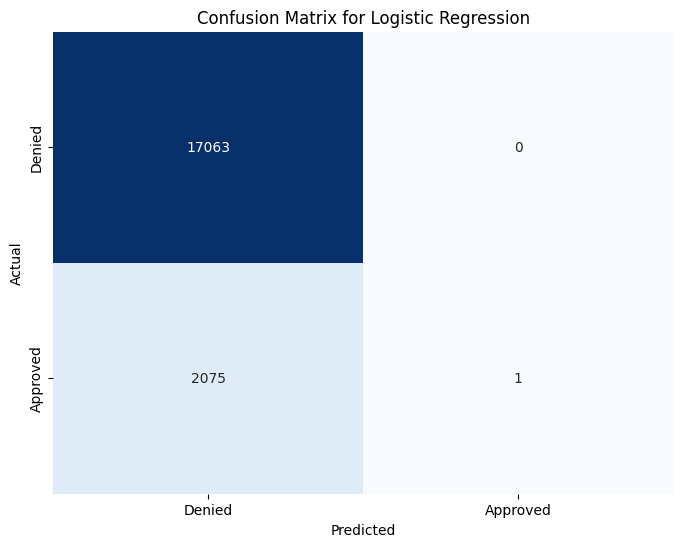

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1] # Probabilities for the positive class

# Evaluate the model
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)
roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)

print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall: {recall_logistic:.4f}")
print(f"F1-Score: {f1_logistic:.4f}")
print(f"ROC-AUC: {roc_auc_logistic:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

# Confusion Matrix
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Denied', 'Approved'], yticklabels=['Denied', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

### 3.2 Decision Tree Classifier Model

Build and interpret a Decision Tree Classifier Model to predict the likelihood of loan approval (Approved = 1).



**Question**
How does the Decision Tree’s accuracy and AUC compare to the Logistic Regression model?

**Answer**
The Decision Tree has lower accuracy (83% vs. 89%), but a higher AUC and much better performance in identifying approved loans, making it more effective than Logistic Regression for this dataset

In [30]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=random_state)
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Classifier model trained successfully.")

Decision Tree Classifier model trained successfully.


Decision Tree Classifier Model Performance:
Accuracy: 0.8283
Precision: 0.2316
Recall: 0.2514
F1-Score: 0.2411
ROC-AUC: 0.5750

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.90     17063
           1       0.23      0.25      0.24      2076

    accuracy                           0.83     19139
   macro avg       0.57      0.57      0.57     19139
weighted avg       0.83      0.83      0.83     19139



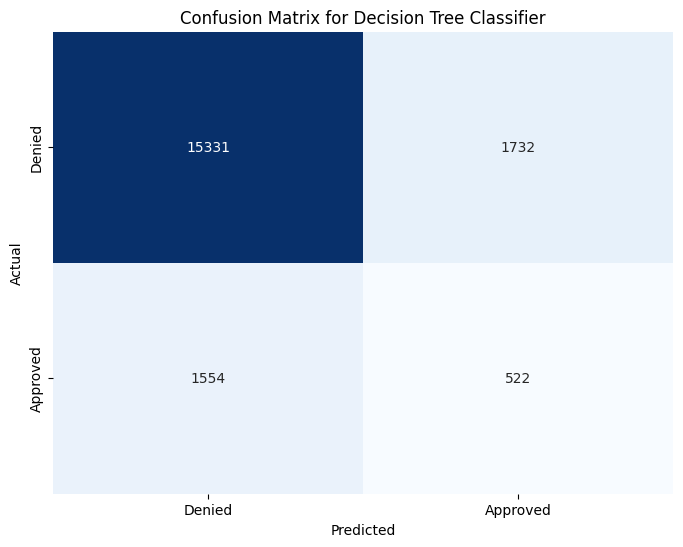

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1] # Probabilities for the positive class

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print(f"Decision Tree Classifier Model Performance:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"ROC-AUC: {roc_auc_dt:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Denied', 'Approved'], yticklabels=['Denied', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

In [32]:
# Variable importance for Decision Tree
feature_importances = decision_tree_model.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances for Decision Tree:")
print(importance_df.head(10))

Top 10 Feature Importances for Decision Tree:
                                     Feature  Importance
26                   Monthly_Housing_Payment    0.247290
24                                FICO_score    0.204064
25                      Monthly_Gross_Income    0.197415
23                       Granted_Loan_Amount    0.098551
2                   Reason_debt_conslidation    0.020943
16  Employment_Sector_information_technology    0.018463
1             Reason_credit_card_refinancing    0.015747
0            Reason_cover_an_unexpected_cost    0.015635
4                      Reason_major_purchase    0.015514
11        Employment_Sector_consumer_staples    0.014127


### Compare the performance of the Logistic Regression and Decision Tree models.

1.   Compare the performance of the Logistic Regression and Decision Tree models.
2.   Evaluate and compare both models using key metrics such as ROC-AUC, Accuracy, Precision, Recall, and F1-score.
3. Plot and interpret the confusion matrices for both models. Discuss what false positives and false negatives mean in the business context (for example, approving risky applicants vs. rejecting qualified ones).
4. Identify which model best captures the target event (loan approval) and explain why.
5. Justify your model choice from both technical (performance, interpretability) and business (actionability, trust, and decision-making) perspectives.
6. Indicate the cutoff threshold you used and why it makes sense for this scenario.

**1 & 2. Model Performance Comparison:**

| Metric        | Logistic Regression | Decision Tree     |
|---------------|---------------------|-------------------|
| Accuracy      | 0.8916              | 0.8283            |
| Precision     | 1.0000              | 0.2316            |
| Recall        | 0.0005              | 0.2514            |
| F1-Score      | 0.0010              | 0.2411            |
| ROC-AUC       | 0.5420              | 0.5750            |

*   **Accuracy**: Logistic Regression has higher overall accuracy (0.8916 vs 0.8283), but because this dataset is imbalaned (89% denied), this metric is misleading for evaluating the ability to identify approved loans.
*   **Precision (Approved Class)**: Logistic Regression shows a Precision of 1.0000, but this is pretty misleading because it only made 1 correct positive prediction out of 2076 actual approved loans. The Decision Tree has a Precision of 0.2316, meaning when it predicts an approval, it is correct about 23% of the time.
*   **Recall (Approved Class)**: Logistic Regression has an extremely low Recall of 0.0005, indicating it failed to identify almost any actual approved loans. The Decision Tree has a much better Recall of 0.2514, meaning it correctly identified about 25% of all actual approved loans.
*   **F1-Score (Approved Class)**: The Decision Tree (0.2411) performs much better than Logistic Regression (0.0010) at identifying the minority class.
*   **ROC-AUC**: The Decision Tree (0.5750) is slightly better than Logistic Regression (0.5420) at distinguishing between approved and denied cases.

**3. Confusion Matrices Interpretation:**

**Logistic Regression Confusion Matrix:**
```
[[17063     0]
 [ 2075     1]]
```
* TN: 17063 → correctly denied loans
* FP: 0 → no risky loans approved
* FN: 2075 → many good applicants wrongly denied
* TP: 1 → almost no correct approvals

This model predicts almost everything as Denied. It avoids risk (no bad approvals) but rejects too many qualified applicants, losing a lot of potential revenue.

**Decision Tree Confusion Matrix:**
```
[[15331  1732]
 [ 1554   522]]
```
* TN: 15331 → correctly denied loans
* FP: 1732 → some risky loans approved
* FN: 1554 → some good applicants rejected
* TP: 522 → many correct approvals

This model is more balanced. It makes some mistakes, but it actually identifies a good number of approved loans.

**4. Which model best captures the target event (loan approval) and why?**


The Decision Tree is better than the Logistic Regression because it can actually identify approved loans, while Logistic Regression almost never does despite it having a higher overall accuracy.

**5. Justify your model choice from both technical and business perspectives.**

*   **Technical Perspective**: The Decision Tree model is technically superior for this task because it handles the class imbalance better. Its Recall (0.2514) and F1-score (0.2411) for the minority class are significantly higher than Logistic Regression (0.0005 Recall, 0.0010 F1-score). While the ROC-AUC is only slightly higher, it's a more realistic indicator of the model's classifying power. The Decision Trees is also more interpretable, allowing us to understand which features drive approval decisions
*   **Business Perspective**: From a business standpoint, the Decision Tree is far more actionable. The Logistic Regression model rejects almost everyone as it failed at identifying approved loans, meaning you would make no revenue. The Decision Tree on the other hand approved qualified applicants, so you would atleast be able to generate revenue

**6. Indicate the cutoff threshold you used and why it makes sense for this scenario.**

0.5 threshold was used for both models, meaning any prediction above 0.5 is classified as approved. This is the standard default and works well for comparing models fairly.



In [37]:
# Import Pipeline to combine preprocessing and model into one object
from sklearn.pipeline import Pipeline
import pickle

# Combine preprocessing and model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', decision_tree_model)
])

# Define filename for saving the model (Colab-compatible path)
filename = 'my_model.pkl'

# Save pipeline to file
with open(r"C:\Users\mopokud\Downloads\my_model.pkl", "wb") as file:
    pickle.dump(model_pipeline, file)

print(f"Model saved successfully to {filename}")

Model saved successfully to my_model.pkl


**Question:**
Which model do you recommend and why? (Provide both technical and business reasoning.)

**Answer:**
I recommend the **Decision Tree Classifier** model for this loan approval prediction task.

* **Technical Reasoning**:
Even though Logistic Regression has higher accuracy, it’s misleading because the data is imbalanced. It predicts almost everything as “Denied” and barely identifies any approved loans. The Decision Tree does a much better job finding approved loans (higher recall and F1-score) and gives more balanced predictions.

* **Business Reasoning**:
From a business standpoint, Logistic Regression would reject almost everyone, leading to no loan approvals and lost revenue. The Decision Tree, while taking on some risk by approving a few bad loans, actually approves many qualified applicants and generates business. It’s also easier to understand, which helps in making better decisions.

## 5. Recommendations
In this final section, summarize your key findings and provide concise business recommendations based on your analysis.


**Write a short paragraph including:**  
- A brief summary of your main findings from the analysis and model comparison.  
- The key factors that most influence loan approval.  
- Your recommendations on data or model based on the results  (for example, how approval decisions could be improved or better understood).  
- One next step you would take to improve the model or extend the analysis further.  


**Add your paragraph here:**

The analysis showed that FICO score, monthly income, and housing payment are the most important factors in loan approval decisions. The data is highly imbalanced, with far fewer approved loans, which caused Logistic Regression to perform poorly by predicting mostly “Denied.” The Decision Tree performed better because it was able to identify more approved loans, making it more useful for the business. Based on this, I would recommend using the Decision Tree model since it balances risk while still allowing approvals and is easier to interpret. To improve results, the model could be enhanced by addressing the class imbalance and further tuning the model to increase accuracy and reliability.

---



**Question:**  What trade-offs or risks should the company be aware of when using this model?  

**Answer:** When using the Decision Tree model, the company should be aware of several trade-offs and risks:
The Decision Tree model has some risks. It may approve some risky loans (false positives), which can lead to financial losses. It also still rejects some qualified applicants (false negatives), meaning missed revenue. Additionally, Decision Trees can overfit the data, so they might not perform as well on new data. While they are generally easy to understand, more complex trees can become harder to make sense of.

**Question:** How confident are you in your model’s generalizability — what might change its performance in real-world use?   

**Answer:**
I have moderate confidence in this model. Its performance could change if the data changes over time (data drift) or if loan approval rules change (concept drift). It may also struggle with new or unusual data it has not seen before.

**Question:** If you had access to additional data, what new feature would you collect to strengthen this model?

**Answer:** If I had access to additional data, I would collect a few simple but important features to better understand an applicant’s financial situation. For example, a debt-to-income ratio would show how much of their income is already going toward debt, helping assess their ability to take on a loan. I would also include payment history, such as whether they consistently pay bills on time, since this reflects reliability. Lastly, job stability (how long they’ve been employed) could indicate steady income and lower risk. These features would help the model make more accurate and realistic loan approval decisions.